# Chatter To Choices: Personalized Stock Recommendations from Social Sentiment

### Contributors:
Cacao, Karl Joseph C.   
Chavez, Miguel Antonio D.   
Libre, Miguel Augustus H.   
Zumel, Jansen Daren C.  

## Methodology

### Overview
This study treats personalized stock recommendation as a collaborative-filtering problem using investor-stock interactions derived from StockTwits messages with explicitly tagged tickers. A sparse user-item utility matrix is used to compare popularity-based, neighborhood-based, and ALS latent-factor recommenders under Monte Carlo cross-validation using NDCG@K, Recall@K, and Diversity@K.

The best-performing recommender is then integrated into a Markowitz portfolio-optimization framework to illustrate practical use, with portfolio performance compared against random allocations through cumulative returns.

### Data Preprocessing
The preprocessing pipeline produces two aligned inputs:  
(1) a sparse user-item utility matrix from StockTwits sentiment data, and  
(2) a daily asset-returns matrix from S\&P 500 price data.

#### 1. Interaction extraction and matrix construction
Raw StockTwits data are reduced to investor ID, asset ticker, and sentiment label. Explicit bullish tags are encoded as $1.0$, explicit bearish tags as $0.0$, and all other cases as missing, yielding

$$
R = \{r_{ui}\}_{u=1,i=1}^{U,I},
$$

where $r_{ui}=1$ denotes a bullish interaction, $r_{ui}=0$ a bearish interaction, and $r_{ui}=\mathrm{NaN}$ no observed interaction. Missing values are preserved as unobserved rather than treated as negative preference.

For the implicit ALS stage used in portfolio integration, the matrix is reindexed to the returns-universe tickers, zero-filled, and converted into binary implicit preferences:

$$
p_{ui} = \mathbb{1}(r_{ui} > 0).
$$

#### 2. Market-price preprocessing
S\&P 500 price data are cleaned separately to form a daily returns matrix. Dates are parsed, the benchmark index $\hat{\text{GSPC}}$ is excluded from the investable universe, and closing prices are converted into simple returns:

$$
r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}.
$$

The cleaned data are then pivoted into a date-by-ticker matrix for optimization and benchmarking.

#### 3. Holdout generation and evaluation setup
Recommendation quality is evaluated through Monte Carlo cross-validation with repeated random holdout splits. For each seed, users with enough positive interactions are eligible, and a fraction of each user's bullish assets is withheld for testing. If

$$
\mathcal{P}_u = \{ i : r_{ui} = 1 \},
$$

then the holdout set $\mathcal{H}_u \subseteq \mathcal{P}_u$ is sampled such that

$$
|\mathcal{H}_u| = \max\left(1, \left\lfloor \text{test\_frac} \cdot |\mathcal{P}_u| \right\rfloor \right).
$$

During evaluation, only items unobserved in training are recommendable:

$$
\mathcal{C}_u = \{ i : r^{\text{train}}_{ui} \text{ is missing} \}.
$$

This same masking rule is applied across all recommender types.

#### 4. Model-specific preprocessing and portfolio link
For neighborhood-based collaborative filtering, missing values are temporarily filled with zeros for cosine-similarity computation, while original missingness is preserved for recommendation masking. Diversity is measured from an item-item similarity matrix derived from the training data:

$$
\mathrm{Diversity@K}(L_u) = 1 - \frac{1}{\binom{K}{2}} \sum_{i < j,\; i,j \in L_u} S(i,j).
$$

After evaluation, the best recommender is aligned to the same ticker universe as the returns matrix so that its outputs can be translated into investor views for the portfolio stage.

### Summary
Overall, preprocessing converts StockTwits sentiment data into a recommendation dataset with explicit train-test separation and prepares aligned return data for portfolio construction. This enables fair recommender comparison and downstream integration with Markowitz optimization.

### Evaluation Methodology
This study evaluates recommendation quality using repeated Monte Carlo holdout splits on the user-item utility matrix. For each random seed, the same train-test split is used for all recommenders so that Popularity, User-User, Item-Item, and ALS are compared on an identical ranking task.

#### 1. Holdout construction
For each seed, a user-level holdout is created by randomly masking a fraction of observed bullish interactions from eligible users. Only users with at least two positive interactions are considered, and approximately 20\% of each eligible user's bullish assets are withheld:

$$
\mathcal{P}_u = \{ i : r_{ui} = 1 \}, \qquad
|\mathcal{H}_u| = \max\left(1,\left\lfloor 0.2 \cdot |\mathcal{P}_u| \right\rfloor\right).
$$

The retained observations form the training matrix, while the hidden bullish interactions form the test set.

#### 2. Common ranking setup
All models recommend only assets that are unobserved in the training matrix:

$$
\mathcal{C}_u = \{ i : r_{ui}^{\text{train}} \text{ is missing} \}.
$$

This same candidate set is used for every recommender. Popularity ranks assets by training-set popularity, User-User uses cosine \(k\)-nearest-neighbor neighborhoods, Item-Item uses cosine item similarity with top-\(k\) pruning, and ALS ranks assets using latent scores from $UV^\top$.

#### 3. Metric calculation and aggregation
For each user in each Monte Carlo split, every recommender produces a ranked list over the same unseen candidate set. From this list, NDCG@50, Recall@50, and Diversity@50 are computed at the user level. These user-level values are then averaged within each split to obtain one seed-level score per model, and the final reported results are the mean and standard deviation of those seed-level scores across all random seeds.

**NDCG@50.**  
For each user, the recommender's ranked list is matched against the held-out test items, where only hidden bullish assets are treated as relevant. Let the resulting relevance vector be

$$
\mathrm{rel}_u = (rel_{u1}, rel_{u2}, \dots).
$$

Discounted Cumulative Gain is computed as

$$
\mathrm{DCG@50}_u
=
\sum_{j=1}^{50}
\frac{rel_{uj}}{\log_2(j+1)}.
$$

This is normalized by the Ideal DCG, computed by placing all of that user's held-out relevant items first within the same candidate set:

$$
\mathrm{NDCG@50}_u
=
\frac{\mathrm{DCG@50}_u}{\mathrm{IDCG@50}_u}.
$$

If a user has no relevant held-out item, the value is treated as missing. The model's seed-level NDCG@50 is the mean of valid user-level NDCG@50 values.

**Recall@50.**  
Recall is computed from the same ranked relevance vector:

$$
\mathrm{Recall@50}_u
=
\frac{\text{number of held-out relevant items appearing in the top 50}}
{\text{total number of held-out relevant items for user } u}.
$$

Because the test set contains only held-out positive interactions, the denominator is simply the number of hidden bullish assets for that user. Users with no held-out positive item are excluded, and the seed-level Recall@50 is the mean across valid users.

**Diversity@50.**  
Diversity is computed from the top-50 recommended items regardless of relevance. Using an item-item cosine similarity matrix derived from the training data, intra-list diversity is defined as

$$
\mathrm{Diversity@50}(L_u)
=
1 - \frac{1}{\binom{50}{2}}
\sum_{i<j,\; i,j \in L_u} S(i,j),
$$

where \(S(i,j)\) is the similarity between recommended assets \(i\) and \(j\). Higher values indicate less redundancy within the recommendation list. If fewer than two items are recommended, diversity is set to \(0\). The seed-level Diversity@50 is the mean of user-level diversity values.

**Aggregate reporting.**  
Aggregation is therefore done in two stages:

1. compute user-level NDCG@50, Recall@50, and Diversity@50 for each recommender within one split, then average across users to obtain one seed-level score per metric;  
2. repeat across random seeds, then report the overall mean and standard deviation of the seed-level scores for each model.

This means the final tables summarize repeated user-level averages across multiple holdout splits, rather than results from only one partition.

###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import black_litterman_recommender as blr
import importlib
from concurrent.futures import ThreadPoolExecutor, as_completed
importlib.reload(blr)

<module 'black_litterman_recommender' from '/home/neo_chavez/AIM/dmw2/final_proj/black_litterman_recommender.py'>

In [3]:
import utils as ut
import data_prep
import markowitz_analysis as ma
import markowitz_plots as mp

In [4]:
df = pd.read_csv('cleaned_ratings.csv', index_col=0)
stock_data_df, stock_data, stock_prices, returns_matrix = data_prep.load_sp500_data("sp500long.csv")

In [5]:
util = blr.stocktwits_to_sentiment_matrix(
    df,
    user_col = "user_id",
    asset_col = "symbol_list",
    sentiment_col = "sentiment",
    bullish_values = (1, "bullish", "Bullish", "BULLISH"),
    bearish_values = (-1,"bearish", "Bearish", "BEARISH"),
)

In [6]:
util = util[returns_matrix.columns.intersection(util.columns)]

In [7]:
U, V, _ = blr.als_explicit(util, 8, lam=0.1, max_iter=50, tol=1e-4, seed=42)

KeyboardInterrupt: 

In [ ]:
seeds = [42, 67, 69, 1337, 420]

res = blr.evaluate_recommenders_parallel(
    util=util,
    U=U,
    V=V,
    seeds=seeds,
    k=50,
    top_k_neighbors=25,
    max_workers=8,
    backend="process",
)

df_ndcg = res["tables"]["ndcg"]
df_recall = res["tables"]["recall"]
df_diversity = res["tables"]["diversity"]

summary_ndcg = res["summary"]["ndcg"]
summary_recall = res["summary"]["recall"]
summary_diversity = res["summary"]["diversity"]
summary_all = res["summary"]["combined"]

# print(df_ndcg.round(4))
# print(df_recall.round(4))
# print(df_diversity.round(4))
# print(summary_all.round(4))

      Popularity  User-User  Item-Item     ALS
Seed                                          
42        0.0079     0.1082     0.1494  0.1955
67        0.0076     0.1073     0.1443  0.1951
69        0.0062     0.1057     0.1509  0.1955
1337      0.0069     0.1086     0.1479  0.1956
420       0.0074     0.1085     0.1456  0.1955
      Popularity  User-User  Item-Item     ALS
Seed                                          
42        0.0347     0.3295     0.5344  0.5461
67        0.0337     0.3275     0.5251  0.5450
69        0.0267     0.3244     0.5428  0.5457
1337      0.0306     0.3298     0.5373  0.5455
420       0.0328     0.3338     0.5325  0.5459
      Popularity  User-User  Item-Item     ALS
Seed                                          
42        0.9418     0.9338     0.9310  0.9347
67        0.9443     0.9349     0.9307  0.9347
69        0.9396     0.9327     0.9299  0.9345
1337      0.9372     0.9339     0.9302  0.9350
420       0.9416     0.9337     0.9306  0.9349
            M

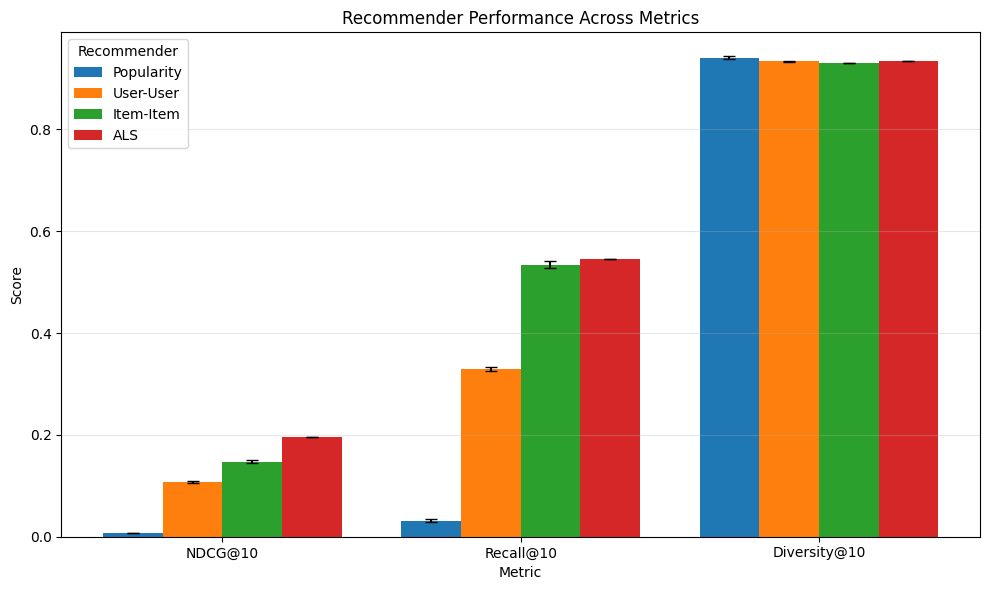

In [ ]:
means_df = pd.DataFrame({
    "NDCG@10": summary_ndcg["Mean NDCG@10"],
    "Recall@10": summary_recall["Mean Recall@10"],
    "Diversity@10": summary_diversity["Mean Diversity@10"],
}).T

stds_df = pd.DataFrame({
    "NDCG@10": summary_ndcg["Std NDCG@10"],
    "Recall@10": summary_recall["Std Recall@10"],
    "Diversity@10": summary_diversity["Std Diversity@10"],
}).T

x = np.arange(len(means_df.index))
n_models = len(means_df.columns)
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(means_df.columns):
    ax.bar(
        x + (i - (n_models - 1) / 2) * width,
        means_df[col].values,
        width=width,
        yerr=stds_df[col].values,
        capsize=4,
        label=col,
    )

ax.set_title("Recommender Performance Across Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(means_df.index)
ax.legend(title="Recommender")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
investor_id = 1209

In [ ]:
recs, scores = blr.recommend_from_als(util, U, V, investor_id, top_n=10)

In [ ]:
stock_data_df, stock_data, stock_prices, returns_matrix = data_prep.load_sp500_data("sp500long.csv")

In [ ]:
returns_train = returns_matrix[returns_matrix.index < "2025-01-01"]
returns_train = returns_train[returns_train.index >= "2024-01-01"]
prior_mu = returns_train[util.iloc[:,recs].columns]
assets = pd.Index(util.iloc[:, recs].columns).astype(str)

R = returns_train.reindex(columns=assets)

# keep only assets with complete data for this window
R = R.dropna(axis=1, how="any")

assets = R.columns

prior_mu = R.mean().to_numpy().reshape(-1, 1)   # (n, 1)
sigma_prior = R.cov().to_numpy()                # (n, n)

tau=0.005
# P must also be built on these same assets, in this exact order
# 

In [ ]:
from sklearn.covariance import LedoitWolf
sigma_prior = LedoitWolf().fit(R).covariance_

In [ ]:
scores = blr.investor_recommender_scores_als(
    M=util,
    U=U,
    V=V,
    investor_id=investor_id,
    exclude_observed=True,
)

In [ ]:
P, Q, Omega, view_table = blr.build_relative_views_from_scores(
    scores=scores[assets],
    tickers=assets,
    sigma_prior=sigma_prior,
    tau=tau,
    n_views=len(assets)//2,
    view_return_scale=0.04 / 252,
    min_confidence = 0.15,
    max_confidence = 0.90,
)

In [ ]:
posterior_mu, posterior_sigma = blr.black_litterman_posterior(
        prior_mu=prior_mu,
        sigma_prior=sigma_prior,
        P=P,
        Q=Q,
        Omega=Omega,
        tau=tau,
    )

In [ ]:
N = len(assets)
min_vol_max_sharpe_bl, _, weights_bl = ut.min_vol_max_sharpe(
    posterior_mu,
    posterior_sigma,
    N,
    R,
    risk_free_rate=0.04 / 252,
)

In [ ]:
# choose one portfolio weights vector
w_bl = weights_bl[1]   # [0] min-vol, [1] max-Sharpe

last_R_date = R.index.max()

# future slice from the full returns matrix
future_returns = returns_matrix.loc[returns_matrix.index > last_R_date]

# portfolio returns on dates after the last date in R
bl_ret_future = (
    future_returns.reindex(columns=w_bl.index) * w_bl
).sum(axis=1)

bl_ret_future.head()

Date
2025-01-02    0.004212
2025-01-03    0.016411
2025-01-06    0.007850
2025-01-07   -0.011567
2025-01-08   -0.020284
dtype: float64

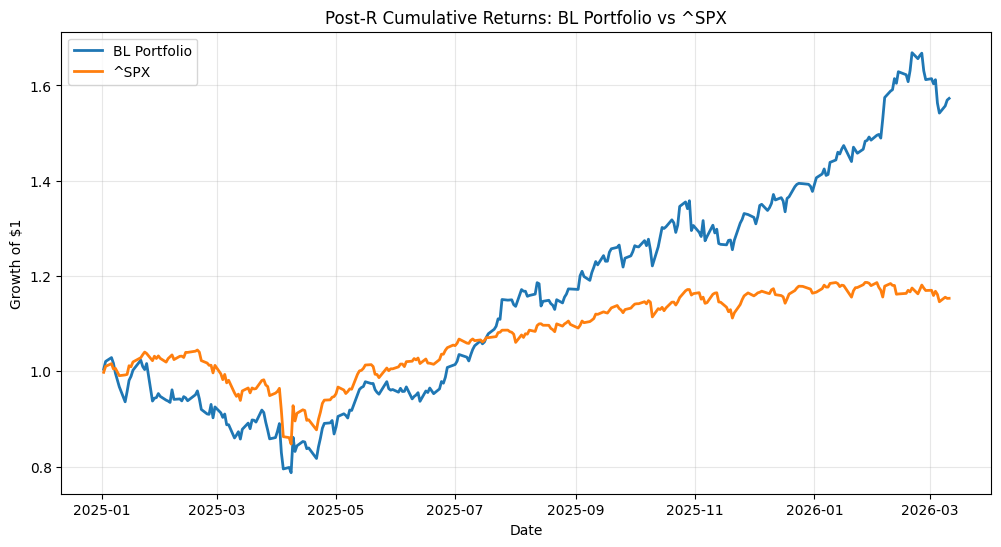

In [ ]:
benchmark_ticker = "^SPX"   # or "^GSPC"

bench_ret_future = future_returns[benchmark_ticker]
if isinstance(bench_ret_future, pd.DataFrame):
    bench_ret_future = bench_ret_future.iloc[:, 0]

plot_df_future = pd.concat(
    [
        bl_ret_future.rename("BL Portfolio"),
        bench_ret_future.rename(benchmark_ticker),
    ],
    axis=1,
).dropna()

cum_df_future = (1 + plot_df_future).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_df_future.index, cum_df_future["BL Portfolio"], label="BL Portfolio", linewidth=2)
plt.plot(cum_df_future.index, cum_df_future[benchmark_ticker], label=benchmark_ticker, linewidth=2)
plt.title(f"Post-R Cumulative Returns: BL Portfolio vs {benchmark_ticker}")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
util[investor_id, recs]